In [ ]:
import os
import sys
sys.path.append(os.path.abspath('..'))

from src.models import train_pipline,auto_tune
from src.utils import show_confusion_matrix,plot_roc_curve

from pytabkit import RealMLP_TD_Classifier
from pytabkit import TabM_D_Classifier
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report

import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [4]:
test_df_FE = pd.read_csv(r'..\data\processed\test_df_FE.csv')
test_df_FE

,alpha,delta,u,g,r,i,z,redshift,spectral_type_A/F,spectral_type_G/K,...,ri_iz,redshift_sq,redshift_low,redshift_mid,redshift_high,sky_x,sky_y,sky_z,z_x_u_g,z_x_g_r
0,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,0,1,...,0.886132,0.184077,0,1,0,-0.466950,0.785815,0.405528,0.736403,0.371335
1,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,0,0,...,0.150513,0.752218,0,0,1,-0.572583,-0.470566,0.671354,2.223866,1.393463
2,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,0,1,...,0.386283,0.050281,0,1,0,-0.993240,0.111959,-0.030650,0.213686,0.207040
3,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,0,1,...,-0.071077,0.004423,1,0,0,-0.996037,-0.085460,-0.024625,0.106024,0.056977
4,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,0,0,...,0.581442,0.954955,0,0,1,-0.711008,-0.651240,0.265243,2.394478,1.486161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247430,248.013903,49.533434,21.563545,21.716868,21.670791,21.265478,21.558618,1.214520,1,0,...,-0.118814,1.475060,0,0,1,-0.242975,-0.601805,0.760785,-0.186214,0.055961
247431,226.823885,52.635936,21.434441,21.075412,20.778300,20.962333,21.010822,1.004950,1,0,...,0.008924,1.009925,0,0,1,-0.415252,-0.442568,0.794795,0.360806,0.298583
247432,232.879335,44.948125,23.294670,22.336583,20.121142,19.405430,18.744581,0.269394,0,0,...,0.472978,0.072573,0,1,0,-0.427122,-0.564333,0.706466,0.258103,0.596826
247433,351.396802,2.451824,20.882944,20.902010,20.222812,20.551737,20.278339,1.199392,0,1,...,-0.089927,1.438542,0,0,1,0.987843,-0.149454,0.042779,-0.022868,0.814625


In [6]:
combined_df_FE = pd.read_csv(r'..\data\processed\combined_df_FE.csv')

X = combined_df_FE.drop(['class'],axis=1)
y = combined_df_FE['class']

X

,alpha,delta,u,g,r,i,z,redshift,color_ug,color_gr,...,sky_x,sky_y,sky_z,z_x_u_g,z_x_g_r,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,galaxy_population_Red_Sequence
0,135.689107,32.494632,23.878820,22.275300,20.395010,19.165730,18.793710,0.634794,1.603520,1.880290,...,-0.603533,0.589187,0.537221,1.017904,1.193596,0,0,1,0,1
1,144.826101,31.274185,24.777590,22.831880,22.584440,21.168120,21.614270,0.779136,1.945710,0.247440,...,-0.698632,0.492354,0.519134,1.515973,0.192789,1,0,0,0,0
2,142.188790,35.582444,25.263070,22.663890,20.609760,19.348570,18.948270,0.644195,2.599180,2.054130,...,-0.642519,0.498590,0.581874,1.674377,1.323259,0,0,1,0,1
3,338.741038,-0.402828,22.136820,23.776560,21.611620,20.504540,19.250100,0.932346,-1.639740,2.164940,...,0.931928,-0.362575,-0.007031,-1.528804,2.018472,0,0,1,0,0
4,345.282593,21.183866,19.437180,17.580280,16.497470,15.977110,15.544610,0.116123,1.856900,1.082810,...,0.901833,-0.236884,0.361362,0.215628,0.125739,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677331,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,1.974528,1.151093,...,-0.724210,-0.688194,0.043684,1.010019,0.588812,0,0,1,0,1
677332,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,1.375570,1.661308,...,-0.545742,-0.525106,0.653015,0.905936,1.094120,0,0,1,0,1
677333,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,0.728394,2.189890,...,0.612052,0.790731,0.011726,0.274125,0.824148,0,0,1,0,1
677334,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,0.347115,0.635191,...,-0.243999,-0.585084,0.773396,0.995651,1.821956,0,1,0,0,0


In [7]:
y

0         0
1         0
2         0
3         0
4         0
         ..
677331    0
677332    0
677333    0
677334    1
677335    1
Name: class, Length: 677336, dtype: int64

In [8]:
target_names =['GALAXY', 'QSO', 'STAR']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
X_resampled

,alpha,delta,u,g,r,i,z,redshift,color_ug,color_gr,...,sky_x,sky_y,sky_z,z_x_u_g,z_x_g_r,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,galaxy_population_Red_Sequence
0,135.689107,32.494632,23.878820,22.275300,20.395010,19.165730,18.793710,0.634794,1.603520,1.880290,...,-0.603533,0.589187,0.537221,1.017904,1.193596,0,0,1,0,1
1,144.826101,31.274185,24.777590,22.831880,22.584440,21.168120,21.614270,0.779136,1.945710,0.247440,...,-0.698632,0.492354,0.519134,1.515973,0.192789,1,0,0,0,0
2,142.188790,35.582444,25.263070,22.663890,20.609760,19.348570,18.948270,0.644195,2.599180,2.054130,...,-0.642519,0.498590,0.581874,1.674377,1.323259,0,0,1,0,1
3,338.741038,-0.402828,22.136820,23.776560,21.611620,20.504540,19.250100,0.932346,-1.639740,2.164940,...,0.931928,-0.362575,-0.007031,-1.528804,2.018472,0,0,1,0,0
4,345.282593,21.183866,19.437180,17.580280,16.497470,15.977110,15.544610,0.116123,1.856900,1.082810,...,0.901833,-0.236884,0.361362,0.215628,0.125739,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1310761,177.431560,42.104660,22.662773,21.871191,21.347481,21.626528,21.449350,0.062489,0.791582,0.523710,...,-0.741163,0.033241,0.670476,0.049899,0.032655,0,1,0,0,0
1310762,336.127061,32.337518,24.596357,23.534624,21.854711,20.437112,19.642284,-0.000025,1.061734,1.679913,...,0.772623,-0.341944,0.534906,-0.000026,-0.000043,0,0,1,0,1
1310763,329.518934,45.426430,21.636586,20.236609,20.001718,19.631741,19.846329,0.055217,1.399978,0.234891,...,0.604828,-0.355997,0.712349,0.077254,0.012876,1,0,0,0,0
1310764,109.699220,0.397565,21.293999,18.852461,17.790088,17.453174,17.134928,0.084338,2.441537,1.062373,...,-0.337073,0.941449,0.006939,0.206073,0.089567,0,0,1,0,1


In [9]:
y_resampled

0          0
1          0
2          0
3          0
4          0
          ..
1310761    2
1310762    2
1310763    2
1310764    2
1310765    2
Name: class, Length: 1310766, dtype: int64

In [10]:
y_resampled.value_counts()

class
0    436922
1    436922
2    436922
Name: count, dtype: int64

In [11]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [12]:
LGBM_params = {
    "n_estimators":("int", 800,2000),
    "max_depth": ("int", 5,9),
    "learning_rate": ("float", 0.02, 0.15,True),
    "subsample": ("float", 0.7, 1.0, False),
    "colsample_bytree":("float", 0.6, 1.0, False),
    "num_leaves": ("int", 50, 200),
    "min_child_samples": ("int", 10, 50),
    "reg_alpha": ("float", 1e-4, 1.0, True),
    "reg_lambda": ("float", 1e-4, 1.0, True),
    'verbose':-1,
}

XGB_params = {
    "n_estimators": ("int",800,2000),
    "max_depth": ("int", 4,8),
    "learning_rate": ("float", 0.02,0.15,True),
    "subsample": ("float", 0.7, 1.0, False),
    "colsample_bytree": ("float", 0.6, 1.0, False),
    "min_child_weight": ("int", 1, 10),
    "reg_alpha": ("float", 1e-4, 1.0, True),
    "reg_lambda":("float", 1e-4, 1.0, True),
    "gamma":  ("float", 0, 0.5, False),
    'verbosity':0,
}

In [ ]:
# RMLP, TabM and ExtraTreesClassifier no need a tuning for them 
# Default tuning is the best and save time

In [13]:
# LGBM_study = auto_tune(X_resampled,y_resampled,LGBMClassifier,LGBM_params,cv=cv,n_trials=30)
# print(LGBM_study.best_params)
# print(LGBM_study.best_value)

In [14]:
# XGB_study = auto_tune(X_resampled,y_resampled,XGBClassifier,XGB_params,cv=cv,n_trials=10)
# print(XGB_study.best_params)
# print(XGB_study.best_value)

In [15]:
LGBM_BEST_PARAMS = {'n_estimators': 1720, 
                    'max_depth': 8, 
                    'learning_rate': 0.1004588162413461, 
                    'subsample': 0.9211068621702558, 
                    'colsample_bytree': 0.6772514761418919, 
                    'num_leaves': 158, 
                    'min_child_samples': 50, 
                    'reg_alpha': 0.0033048591726257772, 
                    'reg_lambda': 0.3411919297680798,
                    'verbose':-1,}

XGB_BEST_PARAMS = {'n_estimators': 1992, 
                   'max_depth': 8, 
                   'learning_rate': 0.1495489475263957, 
                   'subsample': 0.8845406062316428, 
                   'colsample_bytree': 0.7937983404648679, 
                   'min_child_weight': 6, 
                   'reg_alpha': 0.7288130913835621, 
                   'reg_lambda': 0.7211558360849396, 
                   'gamma': 0.2966821082758313,
                   'verbosity':0,}

In [ ]:
# RMLP_model , RMLP_y_preds, RMLP_y_probas= train_pipline(X_resampled,y_resampled,RealMLP_TD_Classifier,cv)
# show_confusion_matrix(y_resampled,RMLP_y_preds,target_names)
# plot_roc_curve(y_resampled,RMLP_y_probas,target_names)
# print(classification_report(y_resampled,RMLP_y_preds,target_names=target_names))

In [ ]:
# TM_model , TM_y_preds, TM_y_probas= train_pipline(X_resampled,y_resampled,TabM_D_Classifier,cv)
# show_confusion_matrix(y_resampled,TM_y_preds,target_names)
# plot_roc_curve(y_resampled,TM_y_probas,target_names)
# print(classification_report(y_resampled,TM_y_preds,target_names=target_names))

In [ ]:
ETC_model , ETC_y_preds, ETC_y_probas= train_pipline(X_resampled,y_resampled,ExtraTreesClassifier,cv)
show_confusion_matrix(y_resampled,ETC_y_preds,target_names)
plot_roc_curve(y_resampled,ETC_y_probas,target_names)
print(classification_report(y_resampled,ETC_y_preds,target_names=target_names))

Cross Validating with LGBMClassifier Model Now...
Fold 1: 0.98228
Fold 2: 0.98215
Fold 3: 0.98243
Fold 4: 0.98231
Fold 5: 0.98214
Mean CV Accuracy: 0.98226



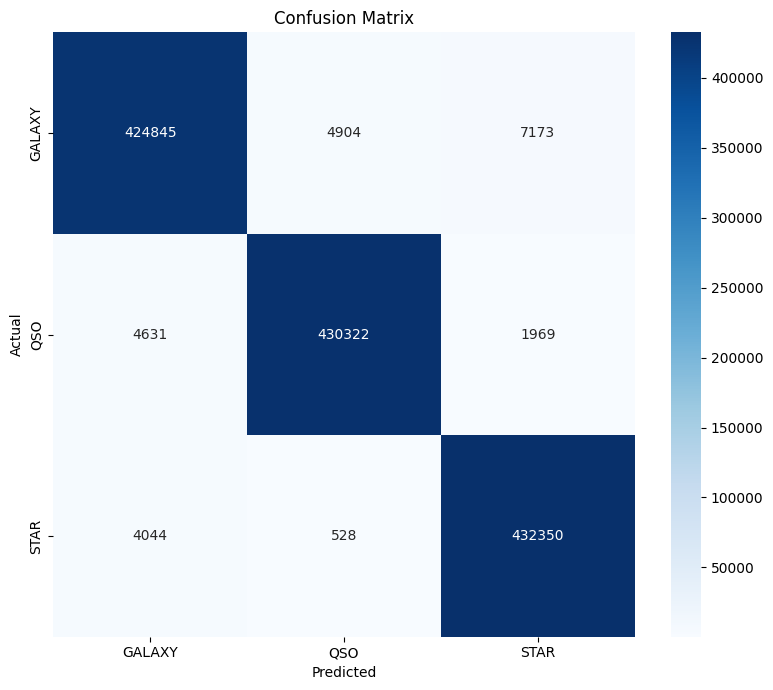

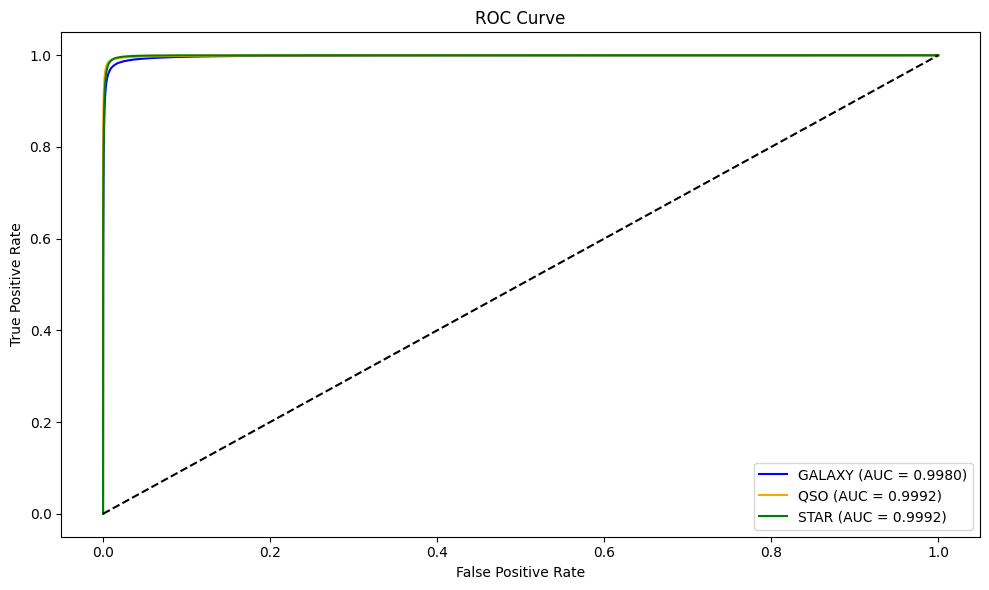

              precision    recall  f1-score   support

      GALAXY       0.98      0.97      0.98    436922
         QSO       0.99      0.98      0.99    436922
        STAR       0.98      0.99      0.98    436922

    accuracy                           0.98   1310766
   macro avg       0.98      0.98      0.98   1310766
weighted avg       0.98      0.98      0.98   1310766



In [22]:
LGBM_model , LGBM_y_preds, LGBM_y_probas= train_pipline(X_resampled,y_resampled,LGBMClassifier,LGBM_BEST_PARAMS,cv)
show_confusion_matrix(y_resampled,LGBM_y_preds,target_names)
plot_roc_curve(y_resampled,LGBM_y_probas,target_names)
print(classification_report(y_resampled,LGBM_y_preds,target_names=target_names))

Cross Validating with XGBClassifier Model Now...
Fold 1: 0.98140
Fold 2: 0.98096
Fold 3: 0.98123
Fold 4: 0.98112
Fold 5: 0.98104
Mean CV Accuracy: 0.98115



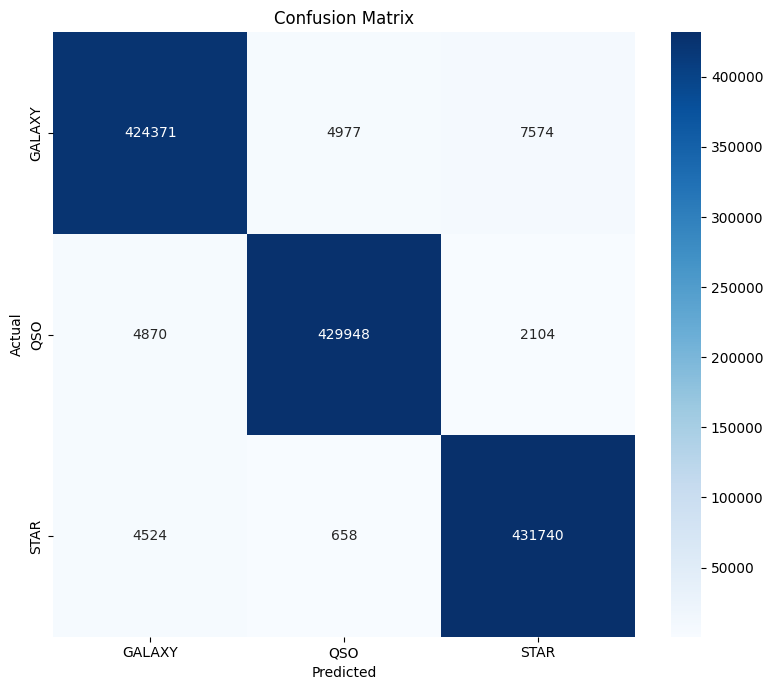

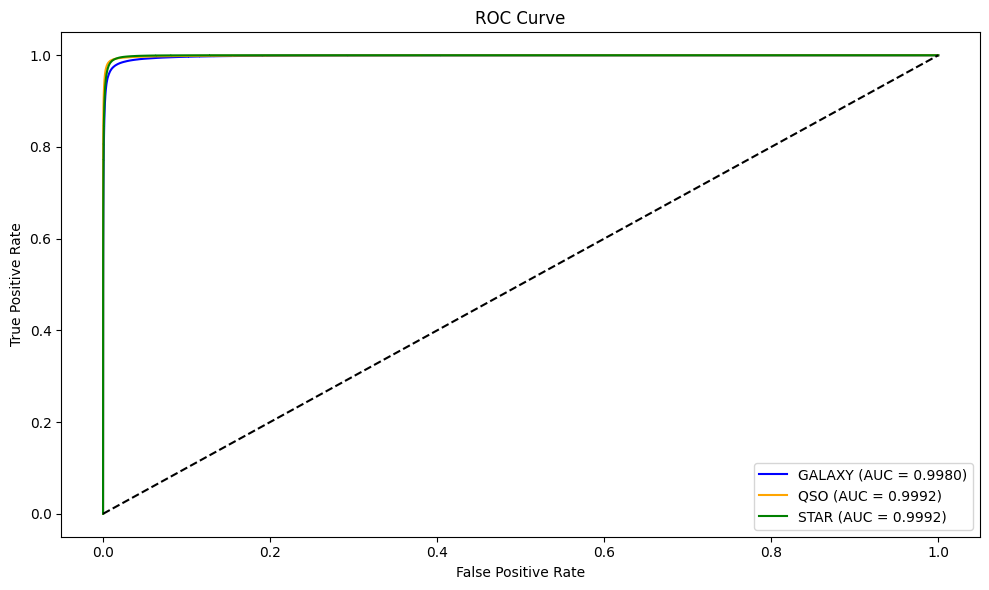

              precision    recall  f1-score   support

      GALAXY       0.98      0.97      0.97    436922
         QSO       0.99      0.98      0.99    436922
        STAR       0.98      0.99      0.98    436922

    accuracy                           0.98   1310766
   macro avg       0.98      0.98      0.98   1310766
weighted avg       0.98      0.98      0.98   1310766



In [23]:
XGB_model , XGB_y_preds, XGB_y_probas= train_pipline(X_resampled,y_resampled,XGBClassifier,XGB_BEST_PARAMS,cv)
show_confusion_matrix(y_resampled,XGB_y_preds,target_names)
plot_roc_curve(y_resampled,XGB_y_probas,target_names)
print(classification_report(y_resampled,XGB_y_preds,target_names=target_names))

In [24]:
np.save('oof_preds/oof_LGBM_preds.npy', LGBM_y_preds)
np.save('oof_preds/oof_LGBM_probas.npy', LGBM_y_probas)

np.save('oof_preds/oof_XGB_preds.npy', XGB_y_preds)
np.save('oof_preds/oof_XGB_probas.npy', XGB_y_probas)